01_EDA_Energy.ipynb

**Sustainable Energy Production & Demand Forecasting**

**Author:** Aman Kumar Singh

1. Imports and Config and Connection Establishment

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")

2. Load Data

In [42]:
data_dir = r"D:\Sustainable-Energy-Forecasting\DataSet"

plants = pd.read_csv(f"{data_dir}/Plants.csv")
prod = pd.read_csv(f"{data_dir}/EnergyProduction.csv", parse_dates=["RecordDate"])
cons = pd.read_csv(f"{data_dir}/Consumption.csv", parse_dates=["RecordDate"])
weather = pd.read_csv(f"{data_dir}/WeatherSnapshots.csv", parse_dates=["SnapshotDate"])
fin = pd.read_csv(f"{data_dir}/Financials.csv", parse_dates=["MonthStart"])
forecast = pd.read_csv(f"{data_dir}/ForecastSnapshots.csv", parse_dates=["ForecastDate"])

3. Quick Data Overview

In [43]:
print("=== Data Shapes ===")
print({
    "Plants": plants.shape,
    "EnergyProduction": prod.shape,
    "Consumption": cons.shape,
    "WeatherSnapshots": weather.shape,
    "Financials": fin.shape,
    "Forecasts": forecast.shape
})
plants.head()

=== Data Shapes ===
{'Plants': (30, 7), 'EnergyProduction': (76710, 8), 'Consumption': (61368, 6), 'WeatherSnapshots': (15342, 7), 'Financials': (2520, 7), 'Forecasts': (15342, 6)}


,PlantID,PlantName,Region,EnergyType,InstalledCapacityMW,CommissionDate,Status
0,1,Plant_001,Coastal,Solar,115.49,2022-02-27,Operational
1,2,Plant_002,South,Solar,285.46,2018-07-29,Operational
2,3,Plant_003,Central,Solar,220.94,2020-05-14,Operational
3,4,Plant_004,North,Solar,181.60,2020-10-31,Operational
4,5,Plant_005,Central,Solar,51.03,2021-08-23,Operational


4. Summary Statistics

In [44]:
print("\n=== Energy Production Summary ===")
print(prod.describe())

print("\n=== Consumption Summary ===")
print(cons.describe())


=== Energy Production Summary ===
       ProductionID       PlantID           RecordDate  EnergyGeneratedMWh  \
count  76710.000000  76710.000000                76710        76710.000000   
mean   38355.500000     15.500000  2021-07-02 00:00:00          996.277193   
min        1.000000      1.000000  2018-01-01 00:00:00            0.000000   
25%    19178.250000      8.000000  2019-10-02 00:00:00          310.462500   
50%    38355.500000     15.500000  2021-07-02 00:00:00          782.451000   
75%    57532.750000     23.000000  2023-04-02 00:00:00         1243.589750   
max    76710.000000     30.000000  2024-12-31 00:00:00         4628.873000   
std    22144.413912      8.655498                  NaN          934.924153   

       DowntimeHours  EfficiencyPct  CO2SavedTons  
count   76710.000000   76710.000000  76710.000000  
mean        0.060269      67.447092    468.238856  
min         0.000000      39.750000      0.000000  
25%         0.000000      58.770000    100.562750  
50

5. Regional Distribution

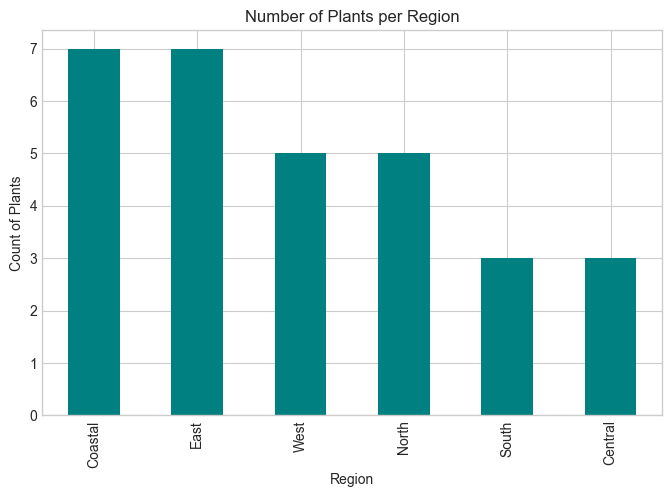

In [45]:
plt.figure(figsize=(8,5))
plants["Region"].value_counts().plot(kind="bar", color="#008080")
plt.title("Number of Plants per Region")
plt.xlabel("Region"); plt.ylabel("Count of Plants")
plt.show()

6. Generation by Energy Type

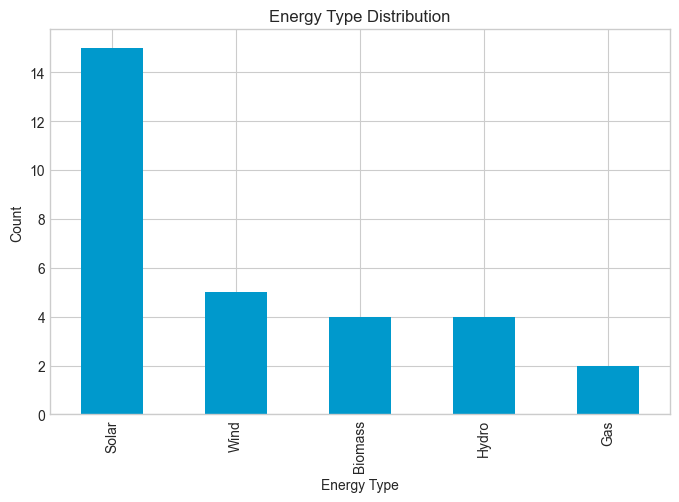

In [46]:
plt.figure(figsize=(8,5))
plants["EnergyType"].value_counts().plot(kind="bar", color="#0099cc")
plt.title("Energy Type Distribution")
plt.xlabel("Energy Type"); plt.ylabel("Count")
plt.show()

7. Average Daily Generation by Region

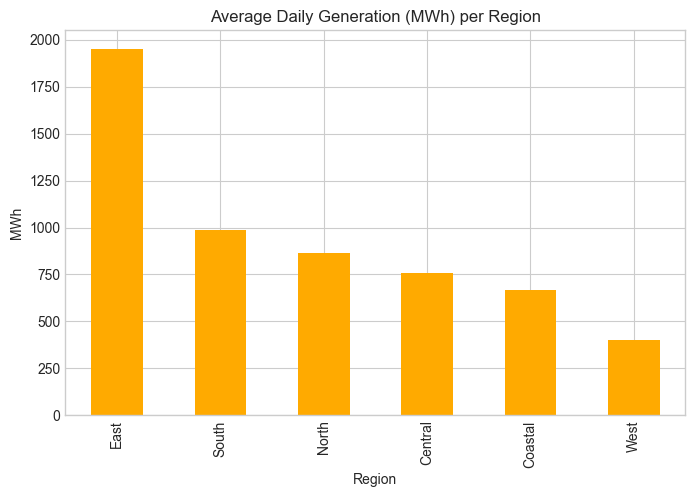

In [47]:
# Ensure no duplicate Region columns
prod_region = prod.drop(columns=["Region"], errors="ignore").merge(
    plants[["PlantID", "Region"]], on="PlantID", how="left"
)

avg_gen = prod_region.groupby("Region")["EnergyGeneratedMWh"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
avg_gen.plot(kind="bar", color="#ffaa00")
plt.title("Average Daily Generation (MWh) per Region")
plt.ylabel("MWh")
plt.show()

8. Efficiency Trends

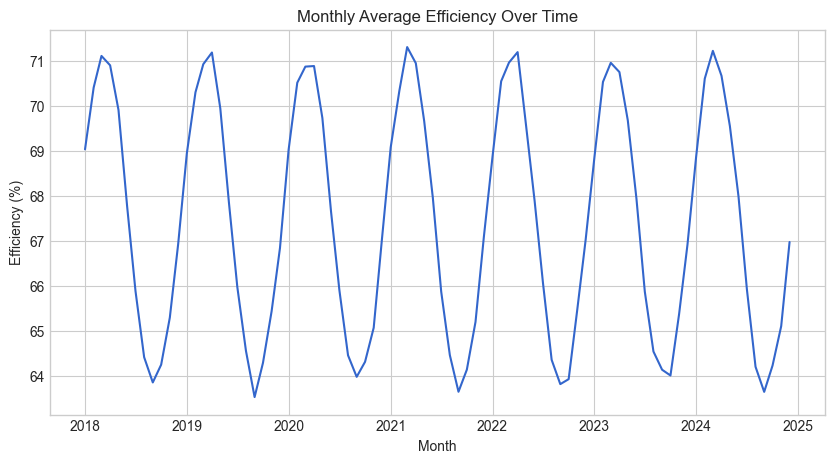

In [48]:
plt.figure(figsize=(10,5))
eff_trend = prod.groupby(prod["RecordDate"].dt.to_period("M"))["EfficiencyPct"].mean()
eff_trend.index = eff_trend.index.to_timestamp()
plt.plot(eff_trend.index, eff_trend.values, color="#3366cc")
plt.title("Monthly Average Efficiency Over Time")
plt.ylabel("Efficiency (%)"); plt.xlabel("Month")
plt.show()

9. Regional Supply vs. Demand

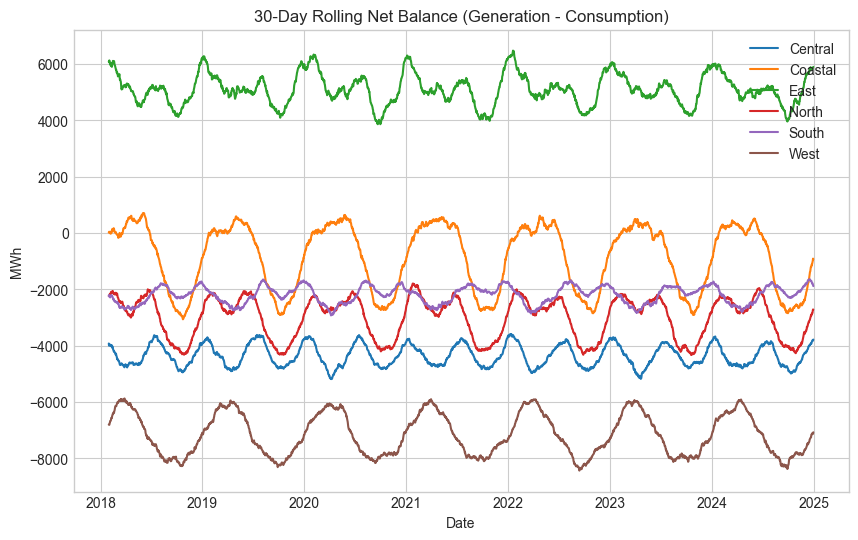

In [49]:
region_daily = prod_region.groupby(["Region","RecordDate"])["EnergyGeneratedMWh"].sum().reset_index()
region_cons = cons.groupby(["Region","RecordDate"])["EnergyConsumedMWh"].sum().reset_index()
merge = pd.merge(region_daily, region_cons, on=["Region","RecordDate"], how="inner")
merge["NetBalance"] = merge["EnergyGeneratedMWh"] - merge["EnergyConsumedMWh"]

plt.figure(figsize=(10,6))
for region in merge["Region"].unique():
    subset = merge[merge["Region"]==region]
    plt.plot(subset["RecordDate"], subset["NetBalance"].rolling(30).mean(), label=region)
plt.legend(); plt.title("30-Day Rolling Net Balance (Generation - Consumption)")
plt.ylabel("MWh"); plt.xlabel("Date")
plt.show()

10. Weather vs. Generation Correlation

In [50]:
merged_weather = prod_region.merge(weather, left_on=["Region","RecordDate"], right_on=["Region","SnapshotDate"])
corr = merged_weather[["SolarRadiation","WindSpeed","RainfallMM","EnergyGeneratedMWh"]].corr()
print("\n=== Weather Correlations with Generation ===")
print(corr["EnergyGeneratedMWh"].sort_values(ascending=False))


=== Weather Correlations with Generation ===
EnergyGeneratedMWh    1.000000
SolarRadiation        0.213980
WindSpeed             0.021757
RainfallMM           -0.007728
Name: EnergyGeneratedMWh, dtype: float64


11. Financial Overview

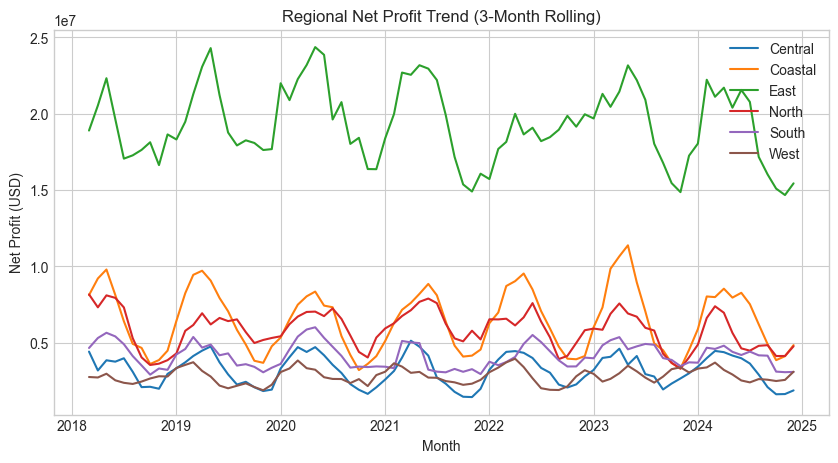

In [51]:
fin_region = fin.merge(plants[["PlantID","Region"]], on="PlantID")
monthly_fin = fin_region.groupby(["Region","MonthStart"])[["RevenueUSD","OperationalCostUSD","NetProfitUSD"]].sum().reset_index()

plt.figure(figsize=(10,5))
for region in monthly_fin["Region"].unique():
    subset = monthly_fin[monthly_fin["Region"]==region]
    plt.plot(subset["MonthStart"], subset["NetProfitUSD"].rolling(3).mean(), label=region)
plt.legend(); plt.title("Regional Net Profit Trend (3-Month Rolling)")
plt.ylabel("Net Profit (USD)"); plt.xlabel("Month")
plt.show()

12. Forecast Accuracy

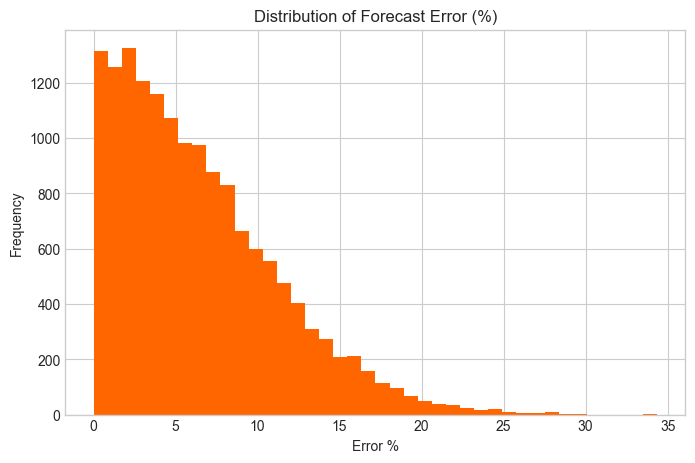

In [52]:
plt.figure(figsize=(8,5))
forecast["ForecastErrorPct"].plot(kind="hist", bins=40, color="#ff6600")
plt.title("Distribution of Forecast Error (%)")
plt.xlabel("Error %"); plt.ylabel("Frequency")
plt.show()

13. Efficiency by Energy Type

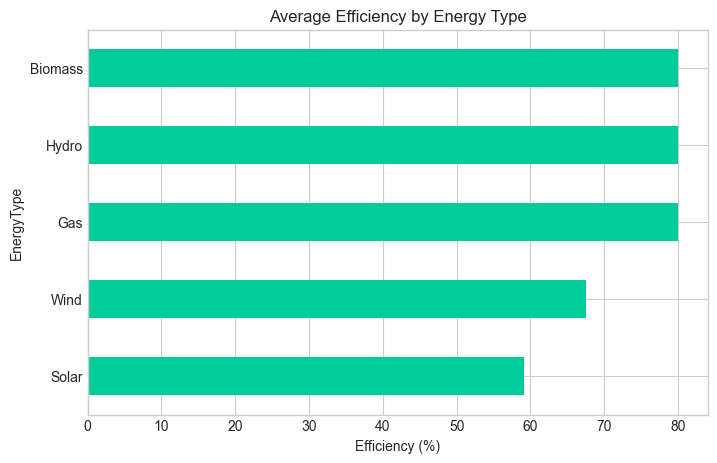

In [53]:
eff_by_type = prod_region.merge(plants, on="PlantID").groupby("EnergyType")["EfficiencyPct"].mean().sort_values()
plt.figure(figsize=(8,5))
eff_by_type.plot(kind="barh", color="#00cc99")
plt.title("Average Efficiency by Energy Type")
plt.xlabel("Efficiency (%)")
plt.show()

14. Top Performing Plants

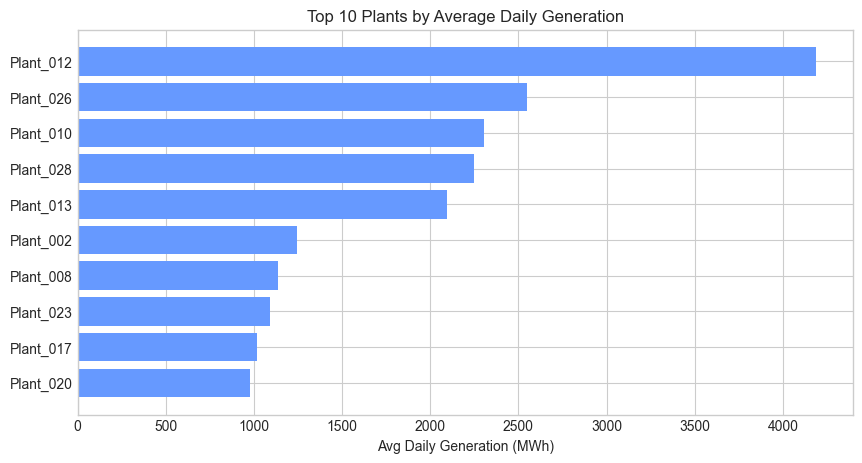

In [54]:
perf = prod_region.groupby("PlantID")[["EnergyGeneratedMWh"]].mean().reset_index()
perf = perf.merge(plants, on="PlantID")
top = perf.sort_values("EnergyGeneratedMWh", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(top["PlantName"], top["EnergyGeneratedMWh"], color="#6699ff")
plt.gca().invert_yaxis()
plt.title("Top 10 Plants by Average Daily Generation")
plt.xlabel("Avg Daily Generation (MWh)")
plt.show()

15. Summary Export

In [55]:
summary = {
    "TotalPlants": len(plants),
    "TotalRecords_Production": len(prod),
    "TotalRecords_Consumption": len(cons),
    "AvgEfficiency": round(prod["EfficiencyPct"].mean(),2),
    "AvgForecastErrorPct": round(forecast["ForecastErrorPct"].mean(),2)
}
print("\n=== Summary KPIs ===")
for k,v in summary.items():
    print(f"{k}: {v}")


=== Summary KPIs ===
TotalPlants: 30
TotalRecords_Production: 76710
TotalRecords_Consumption: 61368
AvgEfficiency: 67.45
AvgForecastErrorPct: 6.42
